In [2]:
import ast
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [3]:
data = {
    'job_skills' : ['py', 'sql', 'java', 'c++', 'c#', 'js', 'html', 'css', 'php', 'ruby'],
    'skill_count' : [30, 25, 20, 10, 5, 4, 6, 30, 1, 2],
    'skill_pay' : [30, 50, 70, 40, 80, 10, 20, 40, 100, 90]
}

df1 = pd.DataFrame(data)

df1

,job_skills,skill_count,skill_pay
0,py,30,30
1,sql,25,50
2,java,20,70
3,c++,10,40
4,c#,5,80
5,js,4,10
6,html,6,20
7,css,30,40
8,php,1,100
9,ruby,2,90


<Axes: xlabel='skill_count', ylabel='skill_pay'>

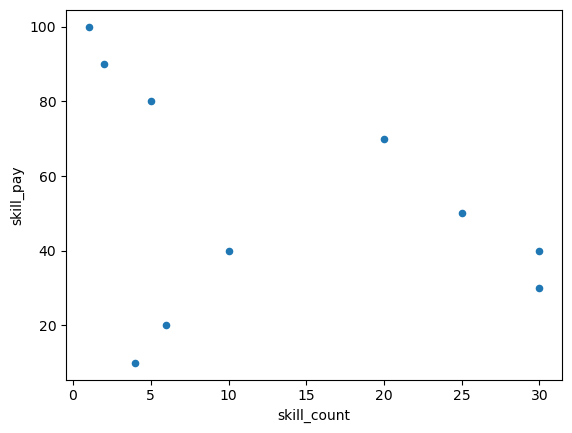

In [4]:
df1.plot(kind='scatter', x='skill_count', y='skill_pay')

In [5]:
df = df[df['job_title_short'] == 'Data Analyst']

df_exploded = df.explode('job_skills')

df_exploded.groupby('job_skills').size()

job_skills
airflow       2002
airtable        88
alteryx       4570
angular        376
angular.js       2
              ... 
wrike           39
wsl             16
xamarin          2
yarn            76
zoom           465
Length: 235, dtype: int64

In [6]:
df_exploded.groupby('job_skills').agg(
    skill_count = ('job_skills', 'count'),
    median_sal = ('salary_year_avg', 'median')
)

,skill_count,median_sal
job_skills,,
airflow,2002,111175.0
airtable,88,90000.0
alteryx,4570,105000.0
angular,376,109101.0
angular.js,2,NaN
...,...,...
wrike,39,75000.0
wsl,16,NaN
xamarin,2,NaN


In [7]:
skill_stats = df_exploded.groupby('job_skills').agg(
    skill_count = ('job_skills', 'count'),
    median_sal = ('salary_year_avg', 'median')
)

skill_stats = skill_stats.sort_values(by='skill_count', ascending=False).head(10)
skill_stats

,skill_count,median_sal
job_skills,,
sql,92428,92500.0
excel,66860,84479.0
python,57190,98500.0
tableau,46455,95000.0
power bi,39380,90000.0
r,29996,92527.5
sas,27998,90000.0
powerpoint,13822,85000.0
word,13562,80000.0


Text(40000, 85000, 'nikita')

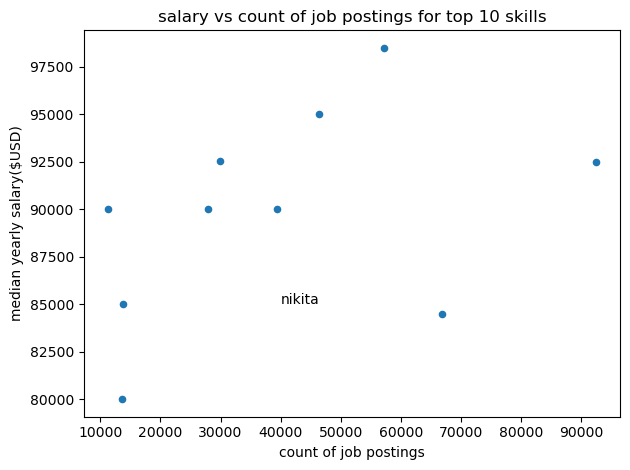

In [8]:
skill_stats.plot(kind='scatter', x='skill_count', y='median_sal')
plt.xlabel('count of job postings')
plt.ylabel('median yearly salary($USD)')
plt.title('salary vs count of job postings for top 10 skills')
plt.tight_layout()
plt.text(40000, 85000, 'nikita')

In [9]:
skill_stats

,skill_count,median_sal
job_skills,,
sql,92428,92500.0
excel,66860,84479.0
python,57190,98500.0
tableau,46455,95000.0
power bi,39380,90000.0
r,29996,92527.5
sas,27998,90000.0
powerpoint,13822,85000.0
word,13562,80000.0


In [10]:
for i, txt in enumerate(skill_stats.index):
    print(i, txt)

0 sql
1 excel
2 python
3 tableau
4 power bi
5 r
6 sas
7 powerpoint
8 word
9 sap


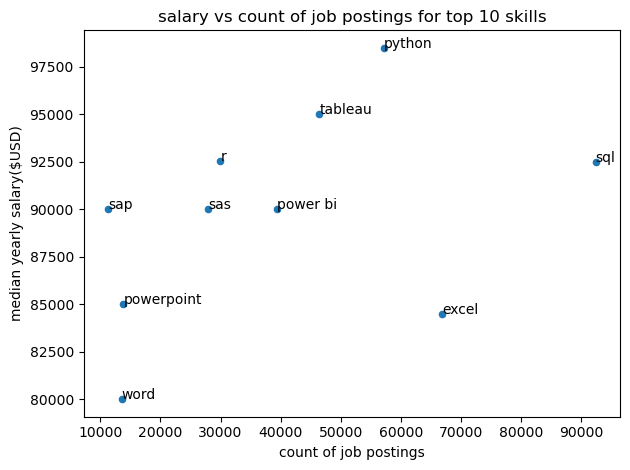

In [11]:
skill_stats.plot(kind='scatter', x='skill_count', y='median_sal')

for i, txt in enumerate(skill_stats.index):
    plt.text(skill_stats['skill_count'].iloc[i], skill_stats['median_sal'].iloc[i], txt)

plt.xlabel('count of job postings')
plt.ylabel('median yearly salary($USD)')
plt.title('salary vs count of job postings for top 10 skills')
plt.tight_layout()


In [13]:
skill_stats = df_exploded.groupby('job_skills').agg(
    skill_count = ('job_skills', 'count'),
    median_sal = ('salary_year_avg', 'median')
)

skill_stats = skill_stats.sort_values(by='skill_count', ascending=False).head(20)
skill_stats

,skill_count,median_sal
job_skills,,
sql,92428,92500.000000
excel,66860,84479.000000
python,57190,98500.000000
tableau,46455,95000.000000
power bi,39380,90000.000000
r,29996,92527.500000
sas,27998,90000.000000
powerpoint,13822,85000.000000
word,13562,80000.000000


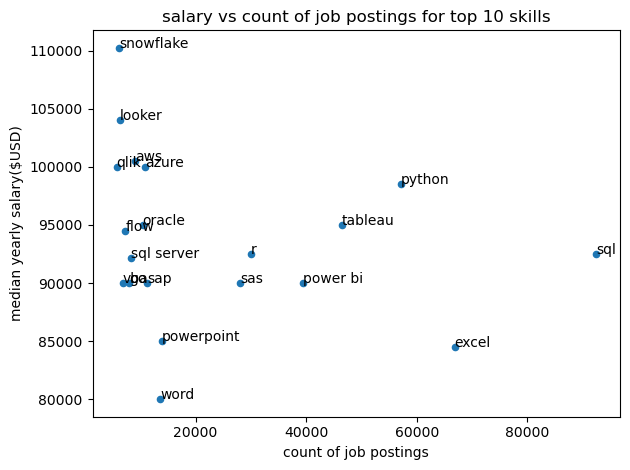

In [14]:
skill_stats.plot(kind='scatter', x='skill_count', y='median_sal')

for i, txt in enumerate(skill_stats.index):
    plt.text(skill_stats['skill_count'].iloc[i], skill_stats['median_sal'].iloc[i], txt)

plt.xlabel('count of job postings')
plt.ylabel('median yearly salary($USD)')
plt.title('salary vs count of job postings for top 10 skills')
plt.tight_layout()


In [ ]:
from adjustText import adjust_text   #to avoid overlapping  provide arrow to dot pointing its name

ModuleNotFoundError: No module named 'adjustText'

NameError: name 'texts' is not defined

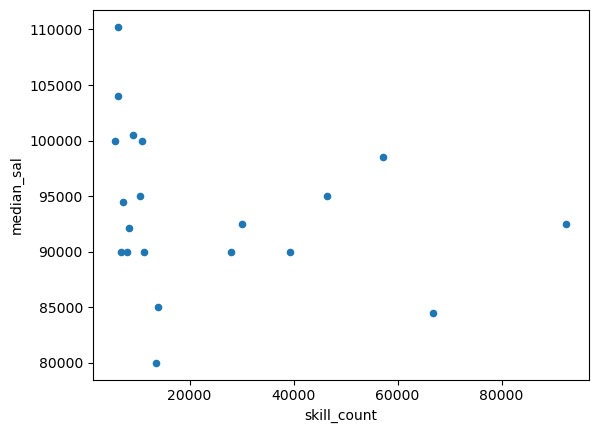

In [19]:
skill_stats.plot(kind='scatter', x='skill_count', y='median_sal')

for i, txt in enumerate(skill_stats.index):
    texts.append(plt.text(skill_stats['skill_count'].iloc[i], skill_stats['median_sal'].iloc[i], txt))


adjust_text(texts)

plt.xlabel('count of job postings')
plt.ylabel('median yearly salary($USD)')
plt.title('salary vs count of job postings for top 10 skills')
plt.tight_layout()
